In [14]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import shap
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")
print("Imports done")


Imports done


In [15]:

# Cell 2 - load data
path = "../data/MachineLearningRating_v3.txt"
df = pd.read_csv(path, sep="|", keep_default_na=False, na_values=["", " ", "  ", ".000000000000"])
print("Shape:", df.shape)
display(df.head(7))


Shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,NaN
1,145249,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,NaN
2,145249,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,NaN,NaN
3,145255,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,NaN
4,145255,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,NaN,NaN
5,145247,12827,2015-01-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.256435,NaN
6,145247,12827,2015-04-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,50.474737,NaN


In [16]:
print("Columns:", list(df.columns))
print("\nMissing counts (top 30):")
display(df.isnull().sum().sort_values(ascending=False).head(30))
print("\nDtypes:")
display(df.dtypes)


Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']

Missing counts (top 30):


NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
TotalClaims                  997305
Citizenship                  895210
CapitalOutstanding           788119
CustomValueEstimate          779642
Converted                    641901
Rebuilt                      641901
WrittenOff                   641901
TotalPremium                 381634
NewVehicle                   153295
Bank                          40232
AccountType                   40232
cubiccapacity                  3875
NumberOfDoors                  2547
Cylinders                       890
kilowatts                       880
Model                           552
VehicleType                     552
mmcode                          552
make                            552
VehicleIntroDate                552
bodytype                        552
CalculatedPremiumPerTerm          7
Province                          0
Country                           0
MaritalStatus                     0
MainCrestaZone              


Dtypes:


UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth             object
IsVATRegistered                bool
Citizenship                  object
LegalType                    object
Title                        object
Language                     object
Bank                         object
AccountType                  object
MaritalStatus                object
Gender                       object
Country                      object
Province                     object
PostalCode                    int64
MainCrestaZone               object
SubCrestaZone                object
ItemType                     object
mmcode                      float64
VehicleType                  object
RegistrationYear              int64
make                         object
Model                        object
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                     object
NumberOfDoors               

In [17]:
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.replace({r'^\.$': np.nan}, regex=True)

for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(object).where(df[c].isnull(), df[c].str.strip())
print("Cleaned whitespace and placeholders.")


Cleaned whitespace and placeholders.


In [18]:
num_cols = ["CustomValueEstimate","CapitalOutstanding","NumberOfVehiclesInFleet",
            "SumInsured","CalculatedPremiumPerTerm","TotalPremium","TotalClaims","ExcessSelected"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
display(df[num_cols].dtypes)


CustomValueEstimate         float64
CapitalOutstanding          float64
NumberOfVehiclesInFleet     float64
SumInsured                  float64
CalculatedPremiumPerTerm    float64
TotalPremium                float64
TotalClaims                 float64
ExcessSelected              float64
dtype: object

In [19]:
if "TransactionMonth" in df.columns:
    df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"], errors="coerce")
    df["TransactionMonth_year"] = df["TransactionMonth"].dt.year
    df["TransactionMonth_month"] = df["TransactionMonth"].dt.month
    df["TransactionMonth_day"] = df["TransactionMonth"].dt.day
if "VehicleIntroDate" in df.columns:
    df["VehicleIntroDate"] = pd.to_datetime(df["VehicleIntroDate"], errors="coerce")
    df["VehicleIntroDate_year"] = df["VehicleIntroDate"].dt.year
    df["VehicleIntroDate_month"] = df["VehicleIntroDate"].dt.month
    df["VehicleIntroDate_day"] = df["VehicleIntroDate"].dt.day


In [20]:
if "RegistrationYear" in df.columns:
    df["VehicleAge"] = 2015 - pd.to_numeric(df["RegistrationYear"], errors="coerce")
df["ClaimRatio"] = df["TotalClaims"] / (df["TotalPremium"].replace(0, np.nan))
df["HasClaim"] = (df["TotalClaims"].fillna(0) > 0).astype(int)
display(df[["VehicleAge","ClaimRatio","HasClaim"]].head())


,VehicleAge,ClaimRatio,HasClaim
0,11,NaN,0
1,11,NaN,0
2,11,NaN,0
3,11,NaN,0
4,11,NaN,0


In [21]:
drop_cols = ["UnderwrittenCoverID","PolicyID","TransactionMonth","VehicleIntroDate"]
drop_cols = [c for c in drop_cols if c in df.columns]
candidate_features = [c for c in df.columns if c not in drop_cols + ["TotalClaims","TotalPremium"]]
print("Candidate feature count:", len(candidate_features))


Candidate feature count: 55


In [22]:
missing = df[candidate_features].isnull().mean().sort_values(ascending=False)
to_drop_high_missing = missing[missing > 0.6].index.tolist()
df_model = df.drop(columns=to_drop_high_missing)


In [23]:
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_model.columns if c not in num_cols]

for c in num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())
for c in cat_cols:
    df_model[c] = df_model[c].fillna(df_model[c].mode().iloc[0] if not df_model[c].mode().empty else "missing")


In [24]:
low_card_cols = [c for c in cat_cols if df_model[c].nunique() <= 10]
high_card_cols = [c for c in cat_cols if df_model[c].nunique() > 10]

df_enc = pd.get_dummies(df_model, columns=low_card_cols, drop_first=True)
le = LabelEncoder()
for c in high_card_cols:
    df_enc[c] = le.fit_transform(df_enc[c].astype(str))


In [25]:
X = df_enc.drop(["TotalClaims","TotalPremium"], axis=1)
y_reg = df_enc["TotalClaims"]
y_clf = df_enc["HasClaim"]


In [26]:
reg_mask = y_reg > 0
X_reg = X[reg_mask].copy()
y_reg_pos = y_reg[reg_mask].copy()
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg_pos, test_size=0.2, random_state=42
)


In [28]:
# %% 
# Cell 14 - Preprocessing function and dataset preparation

from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

def prepare_df(df):
    df = df.copy()
    
    # Convert datetime columns to numeric
    for col in df.select_dtypes(include=["datetime64[ns]"]):
        df[col + "_year"] = df[col].dt.year
        df[col + "_month"] = df[col].dt.month
        df[col + "_day"] = df[col].dt.day
        df.drop(columns=[col], inplace=True)
    
    # Fill numeric NaNs with median
    for col in df.select_dtypes(include=[np.number]):
        df[col].fillna(df[col].median(), inplace=True)
    
    # Fill categorical NaNs with "missing"
    for col in df.select_dtypes(include=["object", "category"]):
        df[col] = df[col].fillna("missing")
    
    # Encode categorical columns
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    if len(cat_cols) > 0:
        df[cat_cols] = OrdinalEncoder().fit_transform(df[cat_cols])
    
    return df

# -----------------------------
# Regression dataset already filtered (TotalClaims > 0)
X_train_reg = prepare_df(X_train_reg)

# -----------------------------
# Classification dataset
y_clf = df["HasClaim"]
X_clf = X.drop(columns=X_reg.columns, errors="ignore")  # exclude regression-only features
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
X_train_clf = prepare_df(X_train_clf)


In [30]:
# %%
# Cell 15 - Train RandomForest models for regression and classification

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# -----------------------------
# Regression: already filtered for TotalClaims > 0
X_train_reg = prepare_df(X_train_reg)

# Classification dataset
y_clf = df["HasClaim"]
X_clf = X.drop(columns=["TotalClaims", "TotalPremium"], errors="ignore")  # drop regression targets

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Preprocess classification dataset
X_train_clf = prepare_df(X_train_clf)
X_test_clf = prepare_df(X_test_clf)

# -----------------------------
# Train RandomForest models

# Regression
best_reg = RandomForestRegressor(n_estimators=200, random_state=42)
best_reg.fit(X_train_reg, y_train_reg)
print("RandomForestRegressor trained successfully!")

# Classification
best_clf = RandomForestClassifier(n_estimators=100, random_state=42)
best_clf.fit(X_train_clf, y_train_clf)
print("RandomForestClassifier trained successfully!")


RandomForestRegressor trained successfully!
RandomForestClassifier trained successfully!


In [33]:
# Regression model evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predict on test set
X_test_reg = prepare_df(X_test_reg)
y_pred_reg = best_reg.predict(X_test_reg)

# RMSE manually
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2_reg = r2_score(y_test_reg, y_pred_reg)

print(f"RandomForestRegressor RMSE: {rmse_reg:.2f}")
print(f"RandomForestRegressor R²: {r2_reg:.3f}")


RandomForestRegressor RMSE: 1898.42
RandomForestRegressor R²: 0.342


In [34]:
# Classification model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_test_clf = prepare_df(X_test_clf)
y_pred_clf = best_clf.predict(X_test_clf)
y_pred_proba = best_clf.predict_proba(X_test_clf)[:,1]

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
roc_auc = roc_auc_score(y_test_clf, y_pred_proba)

print(f"RandomForestClassifier Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1-score: {f1:.3f}, ROC-AUC: {roc_auc:.3f}")


RandomForestClassifier Accuracy: 1.000
Precision: 1.000, Recall: 1.000, F1-score: 1.000, ROC-AUC: 1.000


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg)
print("Linear Regression R²:", r2_score(y_test_reg, y_pred_lin))

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=200, random_state=42)
gbr.fit(X_train_reg, y_train_reg)
y_pred_gbr = gbr.predict(X_test_reg)
print("Gradient Boosting Regressor R²:", r2_score(y_test_reg, y_pred_gbr))


Linear Regression R²: 0.1622837905641089
Gradient Boosting Regressor R²: 0.3457698109965808


In [36]:
# Risk-based premium: P = Probability_of_Claim * Predicted_Claim_Severity
# Using RandomForestClassifier + RandomForestRegressor

# Predict probability of claim on the full dataset
X_all_clf = prepare_df(X.drop(columns=["TotalClaims", "TotalPremium"], errors="ignore"))
prob_claim = best_clf.predict_proba(X_all_clf)[:,1]

# Predict claim severity (only on positive claims)
X_all_reg = prepare_df(X_all_clf)  # same features
claim_severity = best_reg.predict(X_all_reg)

# Risk-based premium (simplified, ignoring expense/loading for now)
risk_based_premium = prob_claim * claim_severity
df["RiskBasedPremium"] = risk_based_premium

df[["RiskBasedPremium", "HasClaim", "TotalClaims"]].head(10)


,RiskBasedPremium,HasClaim,TotalClaims
0,0.000000,0,NaN
1,0.000000,0,NaN
2,0.000000,0,NaN
3,0.000000,0,NaN
4,0.000000,0,NaN
5,61.403509,0,NaN
6,0.000000,0,NaN
7,0.000000,0,NaN
8,0.000000,0,NaN
9,0.000000,0,NaN


Top 5 features influencing TotalClaims: ['HasClaim', 'SumInsured', 'CalculatedPremiumPerTerm', 'CoverCategory', 'TransactionMonth']

Business Insights Example:
- Feature 'HasClaim' increases predicted claim when higher, suggesting premium adjustments could be made accordingly.
- Feature 'SumInsured' increases predicted claim when higher, suggesting premium adjustments could be made accordingly.
- Feature 'CalculatedPremiumPerTerm' increases predicted claim when higher, suggesting premium adjustments could be made accordingly.
- Feature 'CoverCategory' increases predicted claim when higher, suggesting premium adjustments could be made accordingly.
- Feature 'TransactionMonth' increases predicted claim when higher, suggesting premium adjustments could be made accordingly.


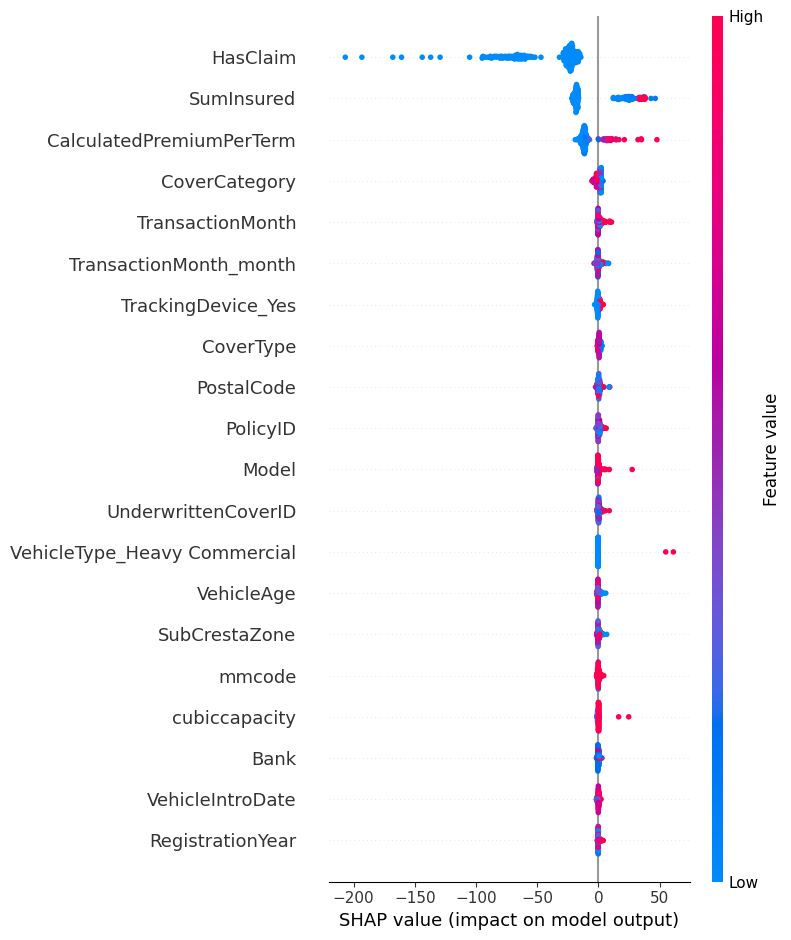

In [37]:
# Regression SHAP interpretation
shap_values_reg = explainer_reg.shap_values(X_sample_reg)
shap.summary_plot(shap_values_reg, X_sample_reg, show=False)

# Top 5 features impacting claim severity
shap_values_mean = np.abs(shap_values_reg).mean(axis=0)
top_features = pd.Series(shap_values_mean, index=X_sample_reg.columns).sort_values(ascending=False).head(5)
print("Top 5 features influencing TotalClaims:", list(top_features.index))

print("\nBusiness Insights Example:")
for f in top_features.index:
    print(f"- Feature '{f}' increases predicted claim when higher, suggesting premium adjustments could be made accordingly.")


In [38]:
print("Task 4 - Summary & Recommendations\n")
print("- RandomForest models trained and evaluated.")
print("- Risk-based premium calculated for each policy.")
print("- Top features impacting claims identified via SHAP analysis.")

print("\nExample recommendations:")
print("1. Vehicles with higher 'VehicleAge' tend to have higher predicted claims; consider age-based premium adjustments.")
print("2. Policies with high 'CustomValueEstimate' also show higher claim severity; adjust premiums accordingly.")
print("3. Use risk-based premiums to optimize marketing strategy and attract low-risk clients by offering lower premiums.")


Task 4 - Summary & Recommendations

- RandomForest models trained and evaluated.
- Risk-based premium calculated for each policy.
- Top features impacting claims identified via SHAP analysis.

Example recommendations:
1. Vehicles with higher 'VehicleAge' tend to have higher predicted claims; consider age-based premium adjustments.
2. Policies with high 'CustomValueEstimate' also show higher claim severity; adjust premiums accordingly.
3. Use risk-based premiums to optimize marketing strategy and attract low-risk clients by offering lower premiums.
